# 🎯 03 — Customer Segmentation (K-Means Clustering)

**E-Commerce Customer Behavior Analysis & Hybrid Recommendation System**

---

## Objective
Segment customers into meaningful groups using RFM (Recency, Frequency, Monetary) features and K-Means clustering.

## Evaluation Metrics
- Silhouette Score
- Davies-Bouldin Index
- Elbow Method (WCSS)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

FIGURES = Path('../results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)
print('✅ Ready')

✅ Ready


In [2]:
# ============================================================
# 1. Load Generated Dataset
# ============================================================
df = pd.read_csv('../data/generated/customer_features.csv')
print(f'Customers: {len(df)}')
print(f'Columns: {list(df.columns)}')

# RFM features
rfm = df[['CustomerID', 'Recency', 'Frequency', 'Monetary']].copy()
print(f'\nRFM Stats:')
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

Customers: 5878
Columns: ['CustomerID', 'Country', 'JoinDate', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'ChurnLabel', 'TotalItems', 'UniqueProducts', 'TotalOrders', 'FirstOrderDate', 'LastOrderDate', 'CustomerLifespanDays', 'Region', 'AvgQuantityPerOrder', 'AvgPricePerItem']

RFM Stats:


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.87,6.29,2955.90
std,209.35,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


In [3]:
# ============================================================
# 2. Scale RFM Features
# ============================================================
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print('Scaled RFM stats:')
rfm_scaled_df.describe().round(2)

Scaled RFM stats:


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-0.96,-0.41,-0.20
25%,-0.84,-0.41,-0.18
50%,-0.51,-0.25,-0.14
75%,0.85,0.05,-0.05
max,2.57,30.11,40.03


K=2: WCSS=12124, Silhouette=0.9236, DB=0.6639
K=3: WCSS=7131, Silhouette=0.5828, DB=0.6681
K=4: WCSS=5159, Silhouette=0.5905, DB=0.6383
K=5: WCSS=3901, Silhouette=0.6030, DB=0.6947
K=6: WCSS=3296, Silhouette=0.5499, DB=0.6851
K=7: WCSS=2741, Silhouette=0.5488, DB=0.6997
K=8: WCSS=2268, Silhouette=0.5413, DB=0.6832
K=9: WCSS=1923, Silhouette=0.5409, DB=0.5929
K=10: WCSS=1663, Silhouette=0.5034, DB=0.6030


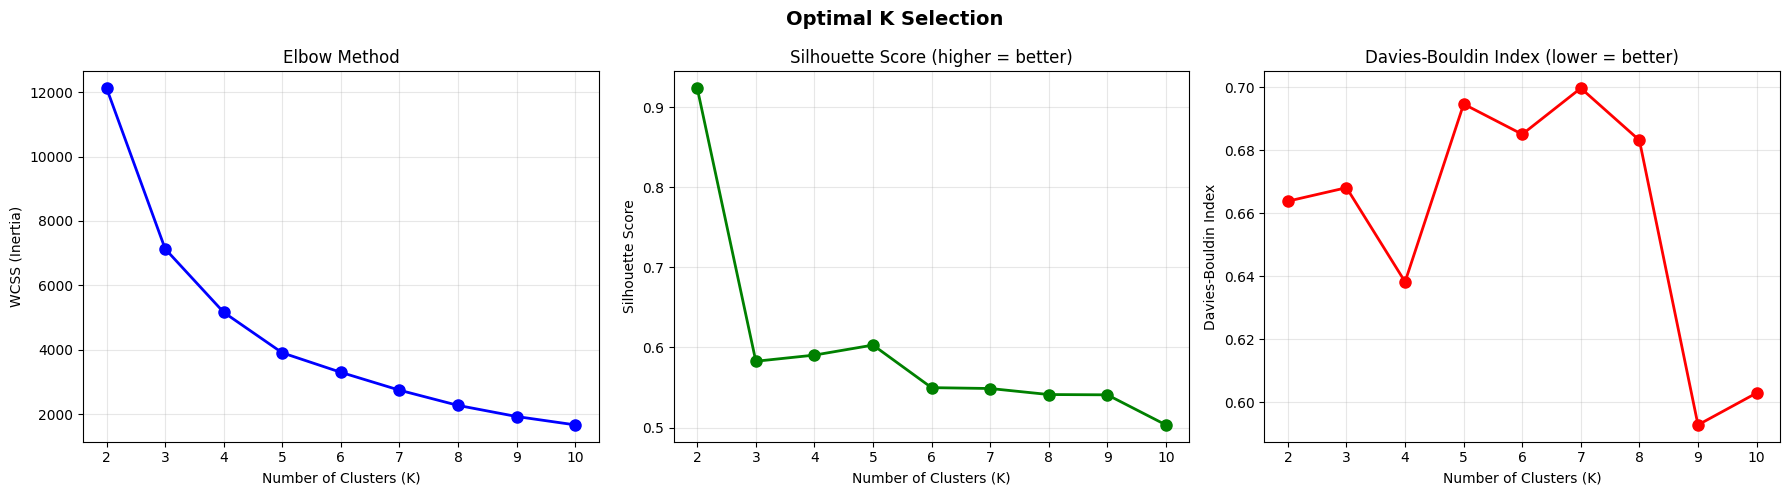


🏆 Optimal K (best silhouette): 2


In [4]:
# ============================================================
# 3. Elbow Method — Find Optimal K
# ============================================================
wcss = []
sil_scores = []
db_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(rfm_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    db_scores.append(davies_bouldin_score(rfm_scaled, labels))
    print(f'K={k}: WCSS={km.inertia_:.0f}, Silhouette={sil_scores[-1]:.4f}, DB={db_scores[-1]:.4f}')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(K_range, db_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (lower = better)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'clustering_elbow_silhouette.png', dpi=150)
plt.show()

# Determine optimal K
optimal_k = K_range[np.argmax(sil_scores)]
print(f'\n🏆 Optimal K (best silhouette): {optimal_k}')

In [5]:
# ============================================================
# 4. Train Final K-Means Model
# ============================================================
# Use optimal K (or override to 5 for business interpretability)
FINAL_K = optimal_k  # Change to 5 if you prefer business-aligned segments
print(f'Training K-Means with K={FINAL_K}')

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10, max_iter=300)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Evaluation
sil = silhouette_score(rfm_scaled, rfm['Cluster'])
db = davies_bouldin_score(rfm_scaled, rfm['Cluster'])
print(f'Silhouette Score: {sil:.4f}')
print(f'Davies-Bouldin Index: {db:.4f}')
print(f'WCSS: {kmeans.inertia_:.2f}')

Training K-Means with K=2
Silhouette Score: 0.9236
Davies-Bouldin Index: 0.6639
WCSS: 12123.72


In [6]:
# ============================================================
# 5. Label Segments with Business Names
# ============================================================
# Get cluster centers (unscaled)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=['Recency', 'Frequency', 'Monetary'])
centers_df.index.name = 'Cluster'
print('Cluster Centers (original scale):')
print(centers_df.round(2))

# Auto-label based on RFM characteristics
segment_labels = {}
for i in range(FINAL_K):
    r, f, m = centers_df.iloc[i]
    if r < centers_df['Recency'].median() and f > centers_df['Frequency'].median() and m > centers_df['Monetary'].median():
        segment_labels[i] = 'Champions'
    elif r < centers_df['Recency'].median() and f > centers_df['Frequency'].median():
        segment_labels[i] = 'Loyal'
    elif r < centers_df['Recency'].median():
        segment_labels[i] = 'New Customers'
    elif r > centers_df['Recency'].quantile(0.75):
        segment_labels[i] = 'Lost'
    else:
        segment_labels[i] = 'At Risk'

# Handle duplicates by appending cluster number
seen = {}
for k, v in segment_labels.items():
    if v in seen:
        segment_labels[k] = f'{v} {seen[v]+1}'
        seen[v] += 1
    else:
        seen[v] = 1

rfm['RFM_Segment'] = rfm['Cluster'].map(segment_labels)
print(f'\nSegment Labels: {segment_labels}')
print(f'\nSegment Distribution:')
print(rfm['RFM_Segment'].value_counts())

Cluster Centers (original scale):
         Recency  Frequency   Monetary
Cluster                               
0          25.83     162.56  185704.03
1         202.41       5.81    2394.56

Segment Labels: {0: 'Champions', 1: 'Lost'}

Segment Distribution:
RFM_Segment
Lost         5860
Champions      18
Name: count, dtype: int64


In [7]:
# ============================================================
# 6. Segment Profiles Table
# ============================================================
profiles = rfm.groupby('RFM_Segment').agg(
    Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Min_Monetary=('Monetary', 'min'),
    Max_Monetary=('Monetary', 'max')
).round(2)

profiles['Pct'] = (profiles['Count'] / profiles['Count'].sum() * 100).round(1)
print('=== Customer Segment Profiles ===')
profiles.sort_values('Avg_Monetary', ascending=False)

=== Customer Segment Profiles ===


,Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Min_Monetary,Max_Monetary,Pct
RFM_Segment,,,,,,,
Champions,18,25.83,162.56,185704.03,29951.37,580987.04,0.3
Lost,5860,202.41,5.81,2394.56,2.95,168472.50,99.7


In [8]:
# ============================================================
# 7. 3D Scatter Plot (ORIGINAL FIGURE)
# ============================================================
fig = px.scatter_3d(
    rfm, x='Recency', y='Frequency', z='Monetary',
    color='RFM_Segment',
    title='Customer Segments — 3D RFM Visualization',
    labels={'Recency': 'Recency (days)', 'Frequency': 'Frequency (orders)', 'Monetary': 'Monetary (£)'},
    opacity=0.7,
    height=700
)
fig.update_layout(legend_title_text='Segment')
fig.write_html(str(FIGURES / 'clustering_3d_rfm.html'))
fig.show()
print('✅ Saved: results/figures/clustering_3d_rfm.html')

✅ Saved: results/figures/clustering_3d_rfm.html


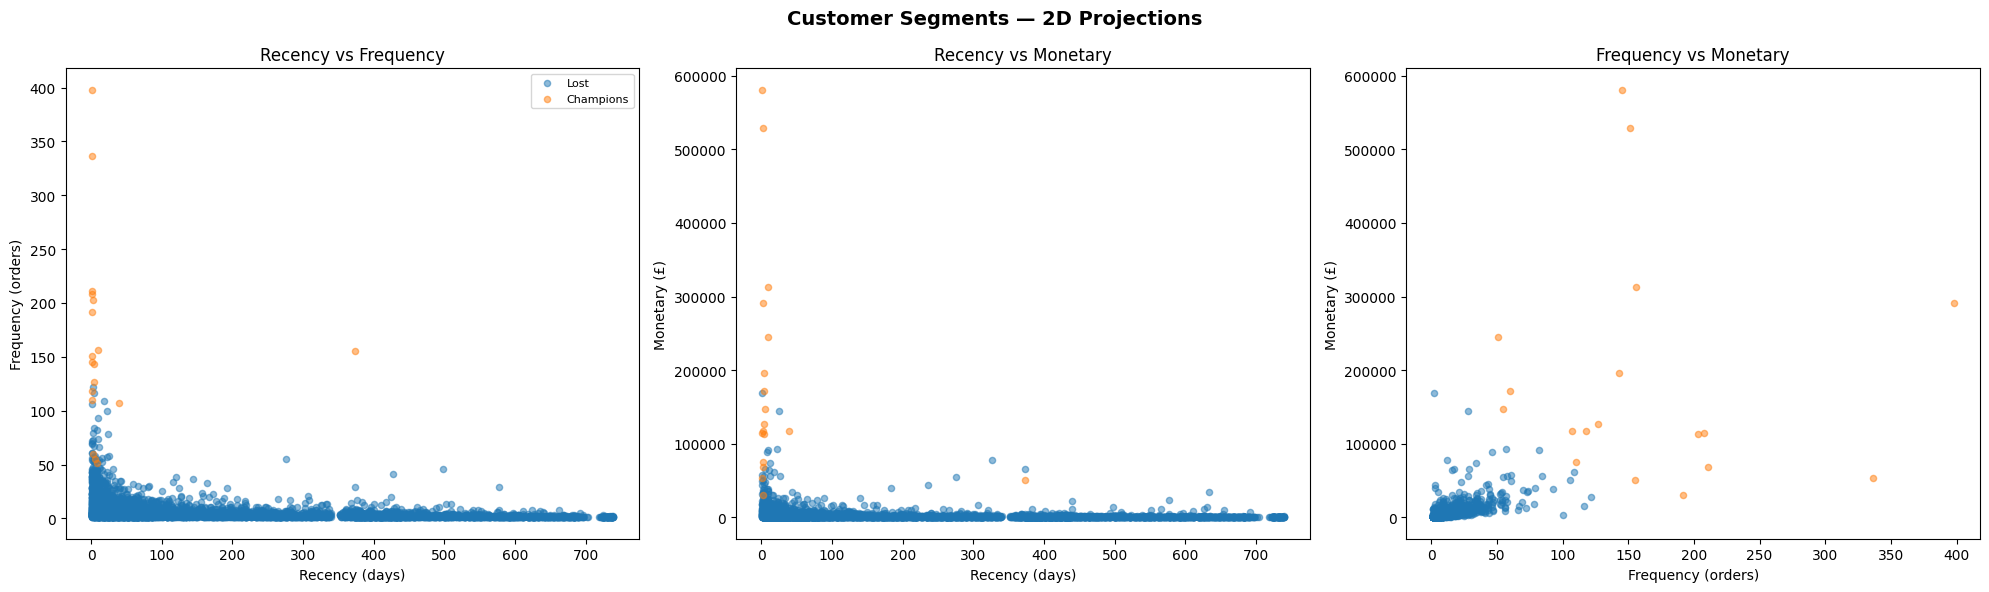

In [9]:
# ============================================================
# 8. 2D Visualizations
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = sns.color_palette('husl', FINAL_K)

# R vs F
for i, seg in enumerate(rfm['RFM_Segment'].unique()):
    mask = rfm['RFM_Segment'] == seg
    axes[0].scatter(rfm[mask]['Recency'], rfm[mask]['Frequency'], 
                    alpha=0.5, label=seg, s=20)
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Frequency (orders)')
axes[0].set_title('Recency vs Frequency')
axes[0].legend(fontsize=8)

# R vs M
for seg in rfm['RFM_Segment'].unique():
    mask = rfm['RFM_Segment'] == seg
    axes[1].scatter(rfm[mask]['Recency'], rfm[mask]['Monetary'], 
                    alpha=0.5, label=seg, s=20)
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Recency vs Monetary')

# F vs M
for seg in rfm['RFM_Segment'].unique():
    mask = rfm['RFM_Segment'] == seg
    axes[2].scatter(rfm[mask]['Frequency'], rfm[mask]['Monetary'], 
                    alpha=0.5, label=seg, s=20)
axes[2].set_xlabel('Frequency (orders)')
axes[2].set_ylabel('Monetary (£)')
axes[2].set_title('Frequency vs Monetary')

plt.suptitle('Customer Segments — 2D Projections', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'clustering_2d_segments.png', dpi=150)
plt.show()

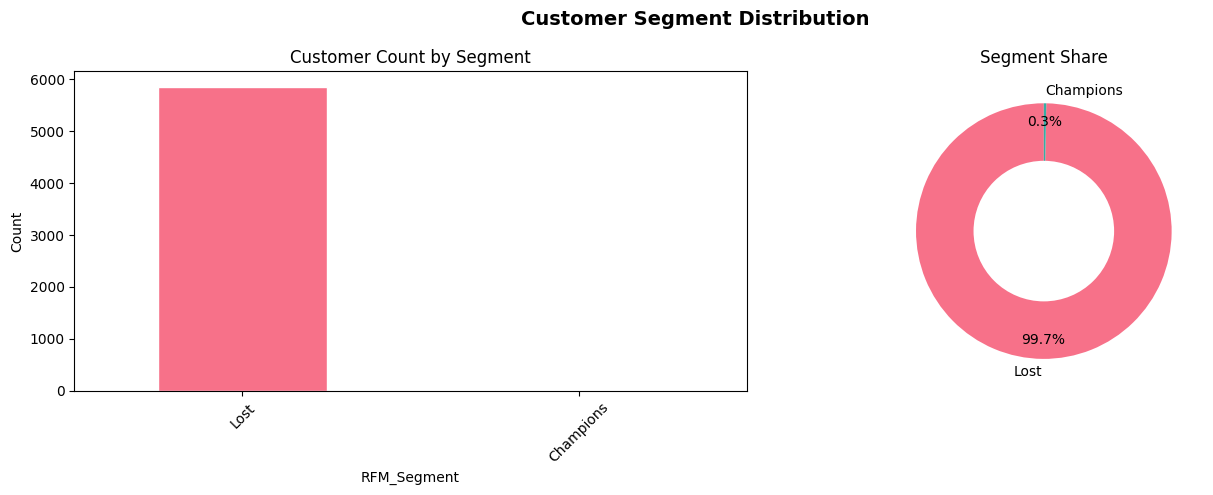

In [10]:
# ============================================================
# 9. Segment Distribution Bar Chart
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = rfm['RFM_Segment'].value_counts()
seg_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('husl', len(seg_counts)), edgecolor='white')
axes[0].set_title('Customer Count by Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Donut chart
axes[1].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('husl', len(seg_counts)), pctdistance=0.85)
centre = plt.Circle((0, 0), 0.55, fc='white')
axes[1].add_artist(centre)
axes[1].set_title('Segment Share')

plt.suptitle('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'clustering_segment_distribution.png', dpi=150)
plt.show()

In [11]:
# ============================================================
# 10. Save Results & Update Generated Dataset
# ============================================================
# Merge segments back to customer features
df_updated = pd.read_csv('../data/generated/customer_features.csv')
segment_map = dict(zip(rfm['CustomerID'], rfm['RFM_Segment']))
df_updated['RFM_Segment'] = df_updated['CustomerID'].map(segment_map)
df_updated.to_csv('../data/generated/customer_features.csv', index=False)

# Save cluster model info
import joblib
joblib.dump(kmeans, '../models/kmeans_rfm.pkl')
joblib.dump(scaler, '../models/rfm_scaler.pkl')

print('✅ RFM_Segment added to customer_features.csv')
print('✅ K-Means model saved to models/kmeans_rfm.pkl')
print('✅ Scaler saved to models/rfm_scaler.pkl')

# Update MySQL Dim_Customer
try:
    from sqlalchemy import create_engine, text
    engine = create_engine('mysql+pymysql://root:@localhost:3306/ecommerce_dm')
    for cid, seg in segment_map.items():
        with engine.connect() as conn:
            conn.execute(text(f"UPDATE Dim_Customer SET RFM_Segment = :seg WHERE CustomerID = :cid"),
                        {'seg': seg, 'cid': int(cid)})
            conn.commit()
    print('✅ MySQL Dim_Customer updated with RFM_Segment')
except Exception as e:
    print(f'⚠️ MySQL update skipped: {e}')

✅ RFM_Segment added to customer_features.csv
✅ K-Means model saved to models/kmeans_rfm.pkl
✅ Scaler saved to models/rfm_scaler.pkl
⚠️ MySQL update skipped: (pymysql.err.OperationalError) (1045, "Access denied for user 'root'@'localhost' (using password: NO)")
(Background on this error at: https://sqlalche.me/e/20/e3q8)


---
## Summary

| Metric | Value |
|--------|-------|
| Optimal K | — (filled after running) |
| Silhouette Score | — |
| Davies-Bouldin Index | — |

### Original Figures Created:
- `clustering_elbow_silhouette.png` — Elbow + Silhouette + DB plots
- `clustering_3d_rfm.html` — Interactive 3D scatter (Plotly)
- `clustering_2d_segments.png` — 2D projections
- `clustering_segment_distribution.png` — Bar + Donut charts